In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
import zipfile
import os

In [3]:
# path to zip file
zip_path = r"C:\Users\Shradha Dedha\Downloads\archive (2).zip"
# extracted file
extract_path = r"C:\Users\Shradha Dedha\Downloads\archive_2_extracted"
#create folder if it doesn't exist
os.makedirs(extract_path , exist_ok = True)
#extract zipfile
with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")
                    

Extraction completed!


In [4]:
extract_path = r"C:\Users\Shradha Dedha\Downloads\archive_2_extracted"
os.listdir(extract_path)

['Heart_Disease_Prediction.csv']

In [5]:
file_path = r"C:\Users\Shradha Dedha\Downloads\archive_2_extracted\Heart_Disease_prediction.csv"
df = pd.read_csv(file_path)
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [6]:
df.shape

(270, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [8]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [9]:
sns.set_theme()

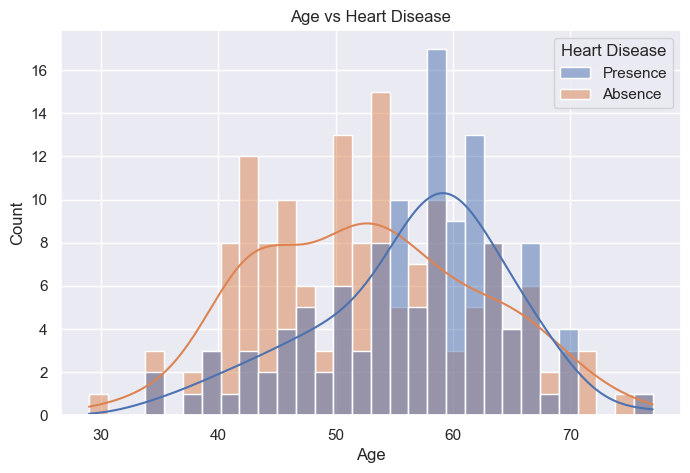

In [12]:
# age vs heart disease
plt.figure(figsize=(8,5))
sns.histplot(data=df , x="Age", hue="Heart Disease", kde=True, bins=30)
plt.title("Age vs Heart Disease")
plt.show()

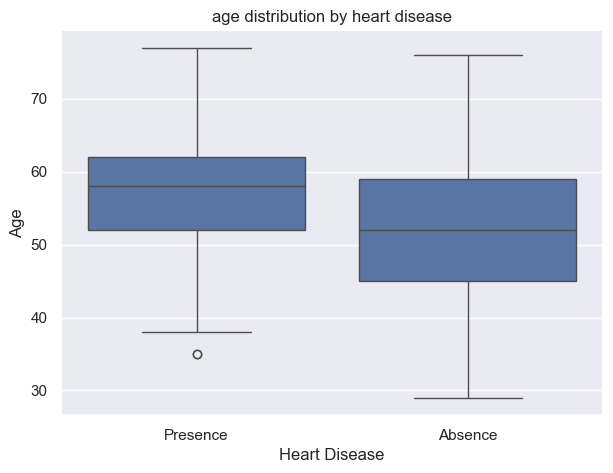

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Heart Disease", y="Age")
plt.title("age distribution by heart disease")
plt.show()

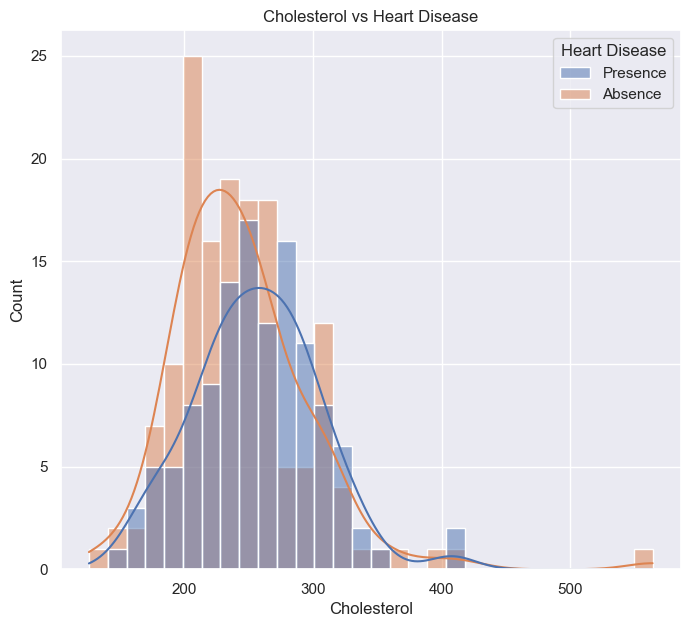

In [16]:
# Cholesterol vs Heart Disease
plt.figure(figsize=(8,7))
sns.histplot(data=df, x="Cholesterol", hue="Heart Disease", kde=True, bins=30)
plt.title("Cholesterol vs Heart Disease")
plt.show()

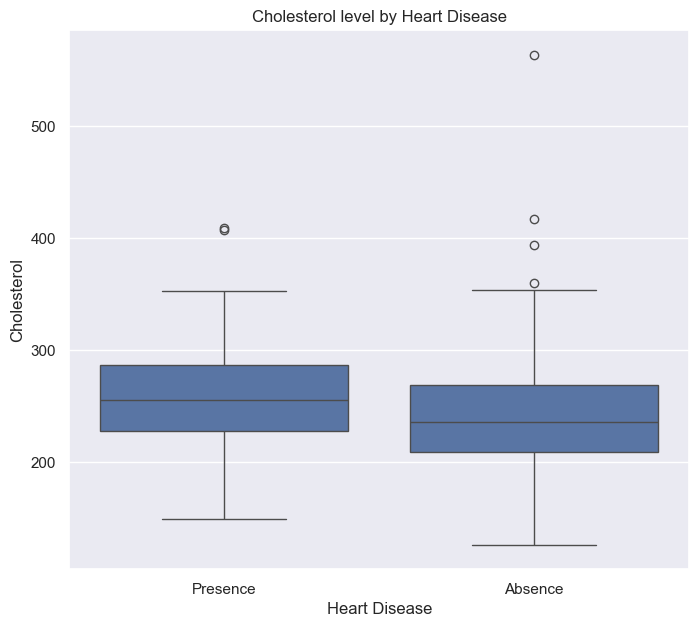

In [17]:
plt.figure(figsize=(8,7))
sns.boxplot(data=df, x="Heart Disease", y="Cholesterol")
plt.title("Cholesterol level by Heart Disease")
plt.show()

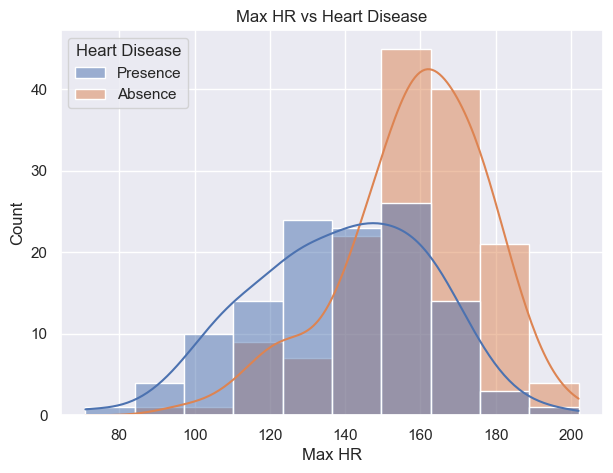

In [18]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x="Max HR", hue="Heart Disease", kde=True,bins= 10 )
plt.title("Max HR vs Heart Disease")
plt.show()

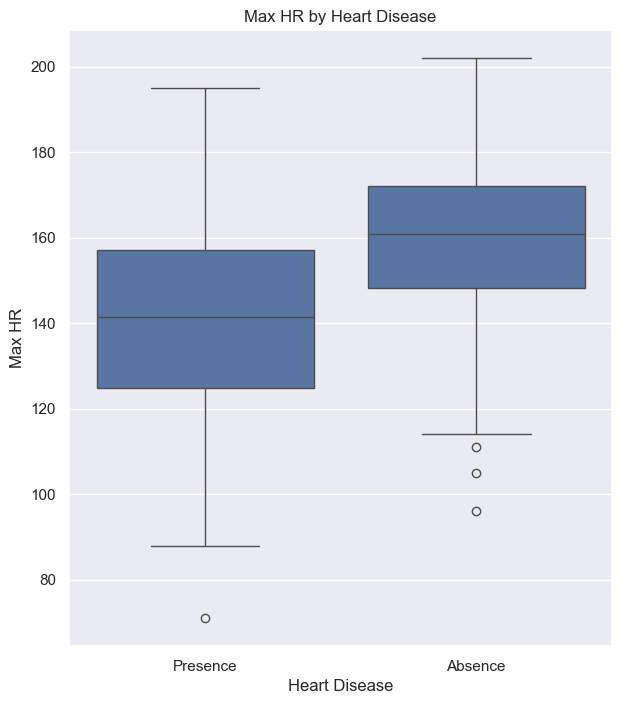

In [20]:
plt.figure(figsize=(7,8))
sns.boxplot(data=df, x="Heart Disease", y="Max HR")
plt.title("Max HR by Heart Disease")
plt.show()

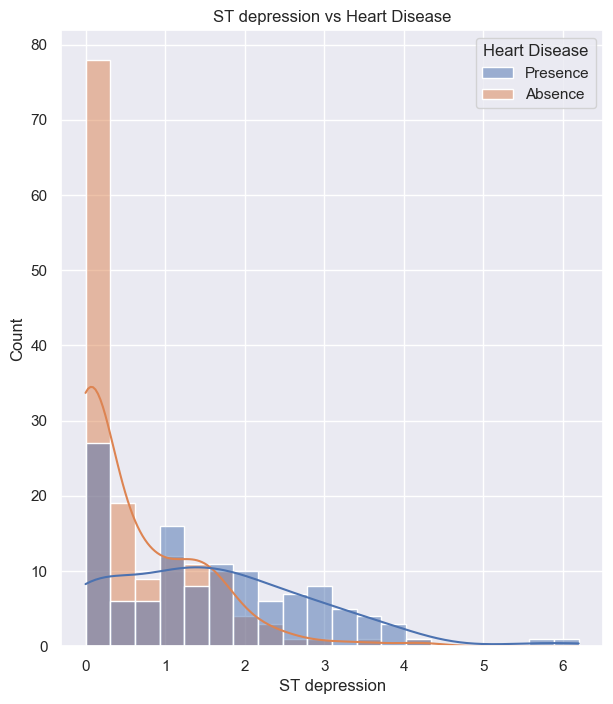

In [22]:
plt.figure(figsize=(7,8))
sns.histplot(data=df, x="ST depression", hue="Heart Disease", kde=True,bins=20)
plt.title("ST depression vs Heart Disease")
plt.show()

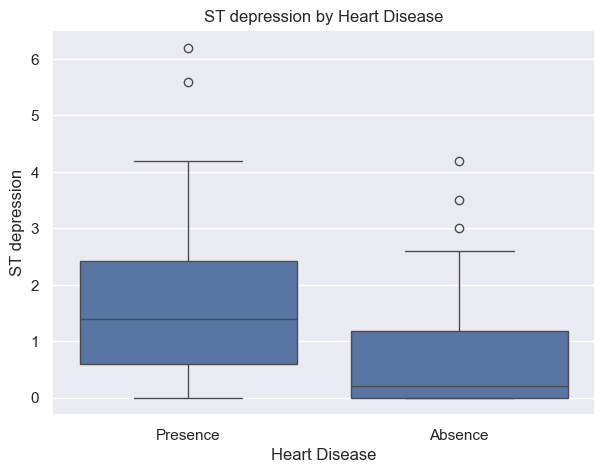

In [23]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Heart Disease",y="ST depression")
plt.title("ST depression by Heart Disease")
plt.show()

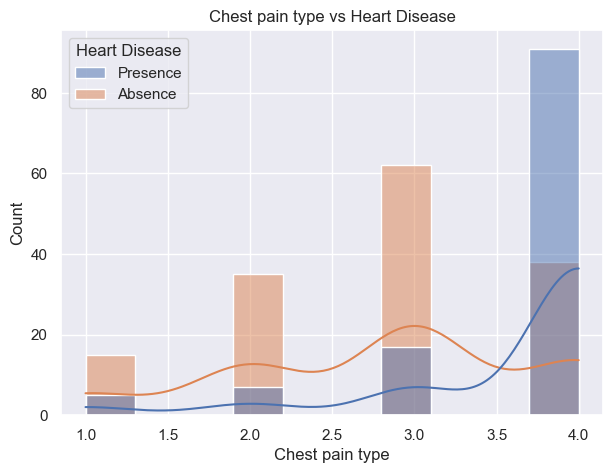

In [25]:
#Chest pain vs Heart Disease
plt.figure(figsize=(7,5))
sns.histplot(data=df,x="Chest pain type", hue="Heart Disease",kde=True,bins=10)
plt.title("Chest pain type vs Heart Disease")
plt.show()

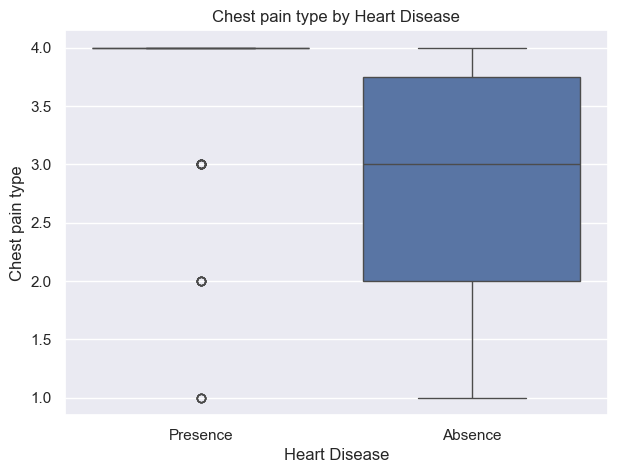

In [26]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Heart Disease",y="Chest pain type")
plt.title("Chest pain type by Heart Disease")
plt.show()

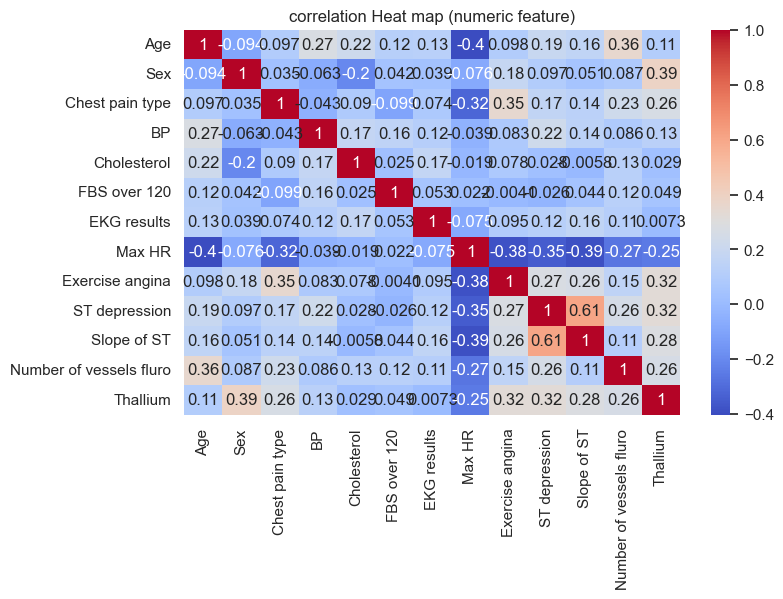

In [35]:
numeric_df= df.select_dtypes (include ="number")
plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(),annot=True,  cmap="coolwarm")
plt.title("correlation Heat map (numeric feature)")
plt.show()



In [39]:
# Encode target values
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence":0,
    "Presence":1
})

In [40]:
# separate feature and tarets
x = df.drop("Heart Disease",axis=1)
y = df["Heart Disease"]
# one hot encode categorical variables
x = pd.get_dummies(x, drop_first= True)

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify= y) 

In [43]:
#featuure scaling for Logistic Regression
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [45]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)

y_pred_log = log_model.predict(x_test_scaled)
y_prob_log = log_model.predict_proba(x_test_scaled)[:,1]

print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))


Logistic Regression Results
[[24  6]
 [ 2 22]]
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54

ROC-AUC: 0.898611111111111


In [46]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

print("\nRANDOM FOREST RESULTS")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))



RANDOM FOREST RESULTS
[[25  5]
 [ 4 20]]
              precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54

ROC-AUC: 0.8666666666666667
